In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/15
    print("準備完了！このまま下のセルを実行できます。")

# 第15章 離散潜在変数 (Discrete Latent Variables)
## 15.3 期待値最大化法 (Expectation–Maximization Algorithm)

本ノートブックでは、Christopher M. Bishop & Hugh Bishop 著『Deep Learning: Foundations and Concepts』(2024年) 第15章「Discrete Latent Variables」の**第15.3節「Expectation–Maximization Algorithm」**、**第15.3.1項「Gaussian mixtures」**、**第15.3.2項「Relation to K-means」**、**第15.3.3項「Mixtures of Bernoulli distributions」**の内容を、完全数式展開・グラフィカルモデル・数値実験・図版再現を通して解説します。

---

### 目次
1. [第15.3.1項 混合ガウス分布に対するEMアルゴリズム (Gaussian mixtures)](#1.-第15.3.1項-混合ガウス分布に対するEMアルゴリズム-(Gaussian-mixtures))
   - 不完全データと対数尤度の課題 (Equation 15.35)
   - Eステップ: 事後負担率の計算 (Equation 15.30)
   - Mステップ: パラメータの再推定 (Equations 15.31 - 15.34)
   - プレート表記による有向グラフィカルモデル (Figure 15.9)
   - Old Faithful 間欠泉データでのEM反復ステップの可視化 (Figure 15.7)
2. [第15.3.2項 K-means との関係 (Relation to K-means)](#2.-第15.3.2項-K-means-との関係-(Relation-to-K-means))
   - 共分散が等方的な場合 $\mathbf{\Sigma}_k = \epsilon \mathbf{I}$ (Equation 15.37)
   - ソフト負担率の表現 (Equation 15.38)
   - $\epsilon \to 0$ におけるハード割当への極限収束 (Equation 15.39)
   - Mステップの極限と K-means 更新式の一致 (Equation 15.40 - 15.41)
   - 複数ガウスによる非凸データ表現: Two Moons (Figure 15.8)
3. [第15.3.3項 ベルヌーイ混合分布 (Mixtures of Bernoulli distributions)](#3.-第15.3.3項-ベルヌーイ混合分布-(Mixtures-of-Bernoulli-distributions))
   - 多変量ベルヌーイ分布の定式化 (Equations 15.42 - 15.43)
   - 対数尤度関数 (Equation 15.45)
   - ベルヌーイEMアルゴリズムの Eステップと Mステップ (Equations 15.46 - 15.49)
   - MNIST手書き数字への適用 (Figure 15.12)
4. [第15.3節のまとめと次節（15.4節 変分下界・ELBO）への展望](#4.-第15.3節のまとめと次節（15.4節-変分下界・ELBO）への展望)


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

# プロジェクトルートの設定
project_root = Path.cwd().parent if Path.cwd().name == '15' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from common.kmeans_clustering import load_faithful_dataset
from common.expectation_maximization import (
    GaussianMixtureEM,
    BernoulliMixtureEM,
    gmm_to_kmeans_limit,
    draw_covariance_ellipse,
    generate_figure_15_7,
    generate_figure_15_8,
    generate_figure_15_9,
    generate_figure_15_12,
)

print("Modules and dependencies successfully loaded!")


Modules and dependencies successfully loaded!


## 1. 第15.3.1項 混合ガウス分布に対するEMアルゴリズム (Gaussian mixtures)

前節（15.2節）で導出したように、混合ガウスモデルの対数尤度関数は次式で与えられます (テキスト式 15.35)：

$$\ln p(\mathbf{X} \mid \boldsymbol{\pi}, \boldsymbol{\mu}, \mathbf{\Sigma}) = \sum_{n=1}^N \ln \left\{ \sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k) \right\} \tag{15.35}$$

各データ点 $\mathbf{x}_n$ に対して和の対数（log-of-sum）が含まれるため、パラメータに関する勾配を 0 と置いた停留条件は閉じた解析解を持たず、パラメータ間に循環依存が生じます。

この課題を解決するのが**期待値最大化法 (Expectation–Maximization, EMアルゴリズム)** です。

---

### EMアルゴリズムの手順

1. **初期化**:
   - 平均 $\boldsymbol{\mu}_k$、共分散行列 $\mathbf{\Sigma}_k$、混合係数 $\pi_k$ の初期値を設定し、初期の対数尤度を計算する。

2. **Eステップ (Expectation step)**:
   - 現在のパラメータ値を用いて、各データ点 $n$ が各成分 $k$ から生成されたとする**事後確率（負担率; responsibilities）** $\gamma(z_{nk})$ を計算する (テキスト式 15.30)：

   $$\gamma(z_{nk}) \equiv p(z_{nk} = 1 \mid \mathbf{x}_n) = \frac{\pi_k \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \mathbf{\Sigma}_j)} \tag{15.30}$$

3. **Mステップ (Maximization step)**:
   - Eステップで計算された負担率 $\gamma(z_{nk})$ を固定し、パラメータを再推定・更新する (テキスト式 15.31 - 15.34)：
   
   $$N_k = \sum_{n=1}^N \gamma(z_{nk}) \tag{15.31}$$
   
   $$\boldsymbol{\mu}_k^{\text{new}} = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) \mathbf{x}_n \tag{15.32}$$
   
   $$\mathbf{\Sigma}_k^{\text{new}} = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) (\mathbf{x}_n - \boldsymbol{\mu}_k^{\text{new}})(\mathbf{x}_n - \boldsymbol{\mu}_k^{\text{new}})^T \tag{15.33}$$
   
   $$\pi_k^{\text{new}} = \frac{N_k}{N} \tag{15.34}$$

4. **収束判定**:
   - 式 (15.35) の対数尤度、あるいはパラメータの変化量を評価する。収束基準を満たしていなければステップ 2 (Eステップ) に戻る。

---

### プレート表記によるグラフィカルモデル (Figure 15.9)
混合ガウスモデルの $N$ 個の独立同分布な観測データ $\mathbf{x}_n$ と対応する潜在変数 $\mathbf{z}_n$、および全データで共有されるパラメータ $\boldsymbol{\pi}, \boldsymbol{\mu}, \mathbf{\Sigma}$ の関係は、次のような**プレート表記 (plate notation)** で美しく表現されます。


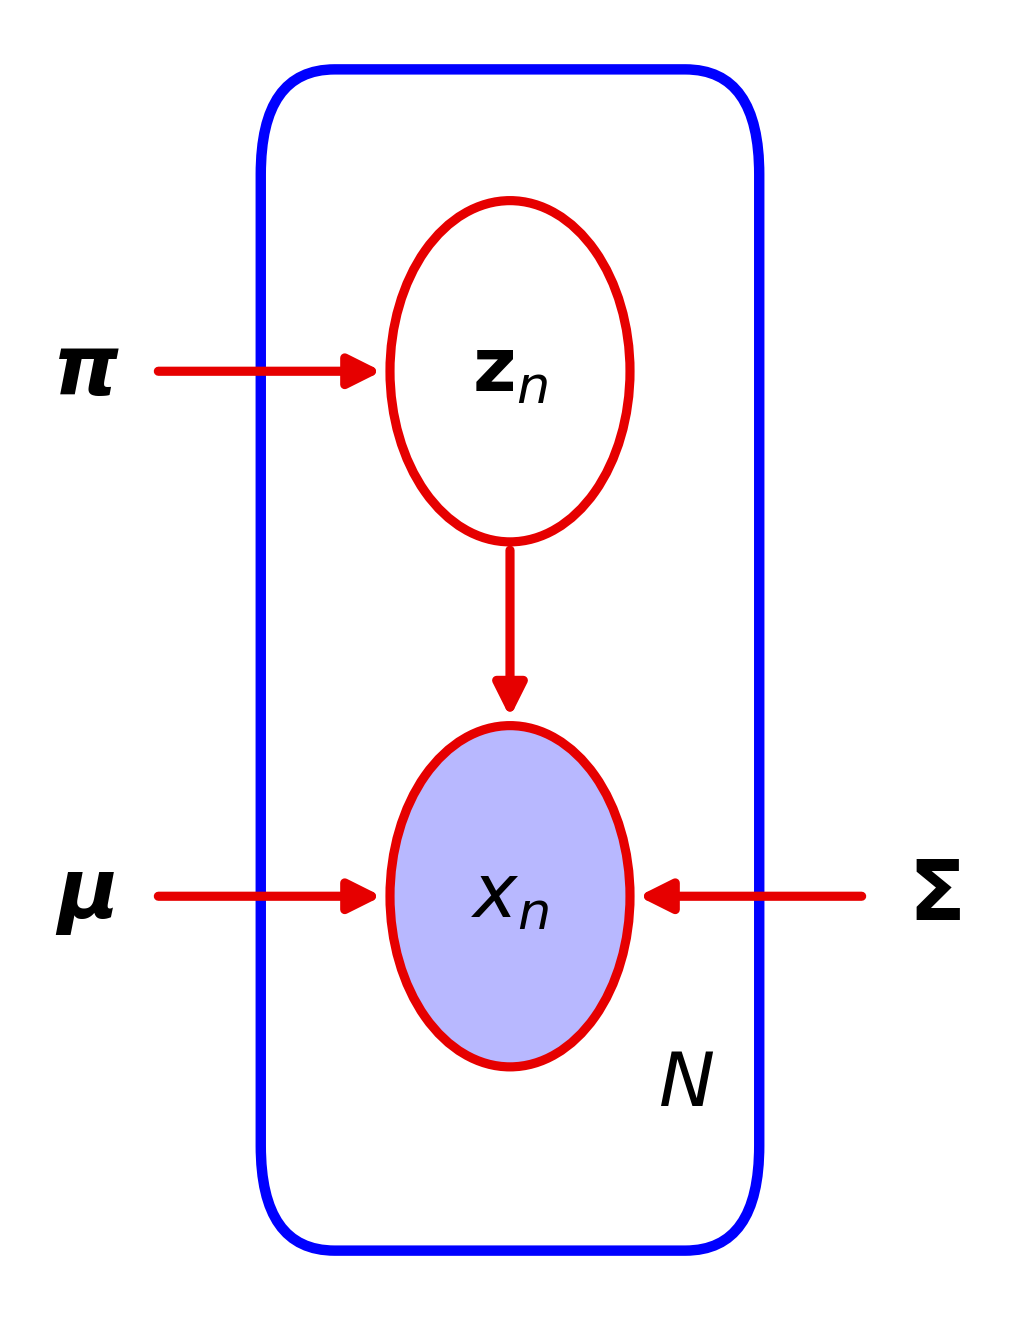

In [2]:
# Figure 15.9: プレート表記グラフィカルモデルの生成と表示
fig_path_15_9 = project_root / "15" / "result" / "fig_15_9_gmm_plate_notation.png"
generate_figure_15_9(fig_path_15_9)

display(Image(filename=str(fig_path_15_9)))


### Old Faithful 間欠泉データにおけるEMアルゴリズムの挙動 (Figure 15.7)

テキスト Figure 15.7 に忠実に従い、標準化された Old Faithful データセットに対して $K=2$ の混合ガウスモデルを適用します。
初期値として以下のパラメータを設定します：
- 平均ベクトル： $\boldsymbol{\mu}_1 = (-1.5, 1.0)^T$, $\boldsymbol{\mu}_2 = (1.5, -1.0)^T$
- 共分散行列： $\mathbf{\Sigma}_1 = \mathbf{\Sigma}_2 = \mathbf{I}$ （単位行列、円形）
- 混合係数： $\pi_1 = \pi_2 = 0.5$

各ステップでの状態を観察します：
- **(a) 反復 0 (初期状態)**: データ点は緑色で表示され、2つの円形ガウス成分（1標準偏差の楕円）が配置されている。
- **(b) 反復 1 Eステップ**: 現在の平均・共分散をもとに負担率 $\gamma(z_{n1}), \gamma(z_{n2})$ が計算され、データ点が青と赤の比率に応じた色で塗られる。
- **(c) 反復 1 Mステップ**: 負担率の重み付き平均・共分散により、成分の中心と楕円形状が更新される。
- **(d) 反復 2**: 2回目のEM反復後の状態。
- **(e) 反復 5**: 5回目のEM反復後の状態。
- **(f) 反復 20**: 20回目のEM反復後（ほぼ完全に収束した状態）。


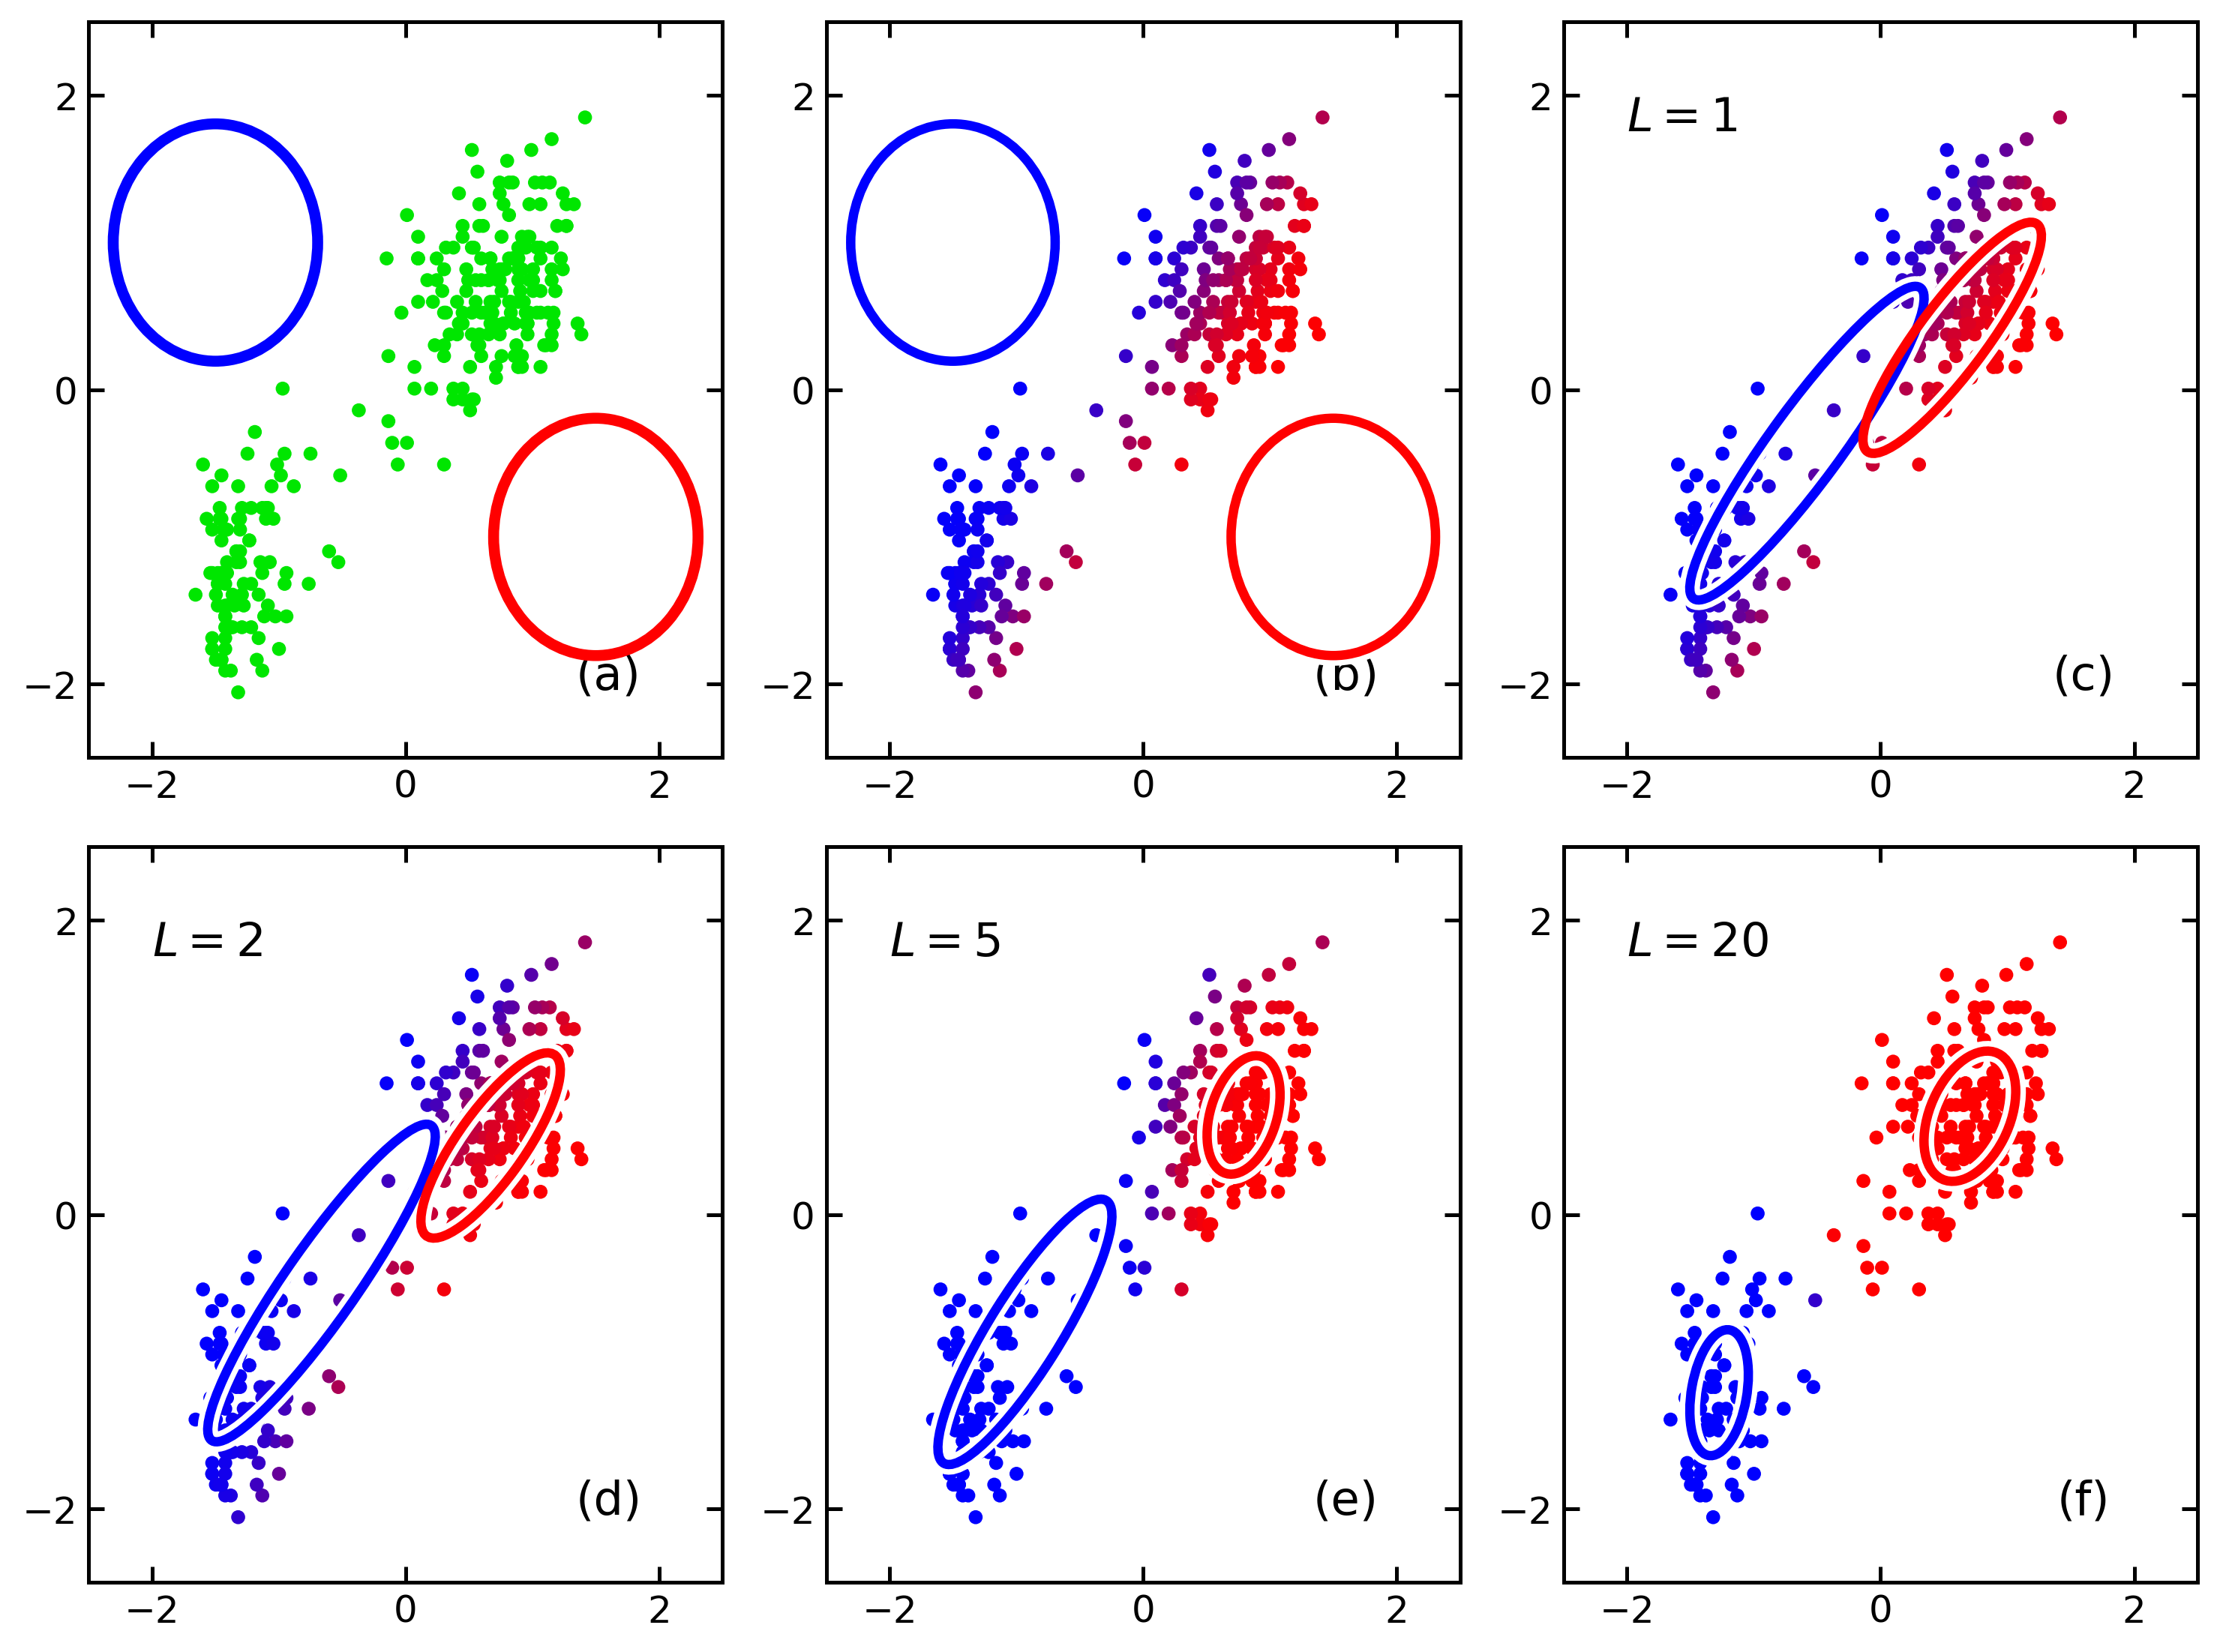

Log-likelihood progression at M-steps (first 5 and final):
  Iteration  1: ln p(X) = -536.8878
  Iteration  2: ln p(X) = -527.8719
  Iteration  3: ln p(X) = -502.6243
  Iteration  4: ln p(X) = -461.5516
  Iteration  5: ln p(X) = -448.4561
  Iteration 20: ln p(X) = -385.4607


In [3]:
# Figure 15.7: Old Faithful データセットに対するEMアルゴリズムの反復過程
fig_path_15_7 = project_root / "15" / "result" / "fig_15_7_em_old_faithful.png"
generate_figure_15_7(fig_path_15_7)

display(Image(filename=str(fig_path_15_7)))

# 対数尤度の推移を確認
X_std, _ = load_faithful_dataset()
init_means = np.array([[-1.5, 1.0], [1.5, -1.0]])
init_covs = np.array([np.eye(2), np.eye(2)])
init_weights = np.array([0.5, 0.5])

em_model = GaussianMixtureEM(n_components=2, max_iter=20)
em_model.fit_with_custom_init(X_std, init_means, init_covs, init_weights)

m_lls = [h["log_likelihood"] for h in em_model.history_ if h["step"] == "M"]
print("Log-likelihood progression at M-steps (first 5 and final):")
for i, ll in enumerate(m_lls[:5]):
    print(f"  Iteration {i+1:2d}: ln p(X) = {ll:.4f}")
print(f"  Iteration 20: ln p(X) = {m_lls[-1]:.4f}")


## 2. 第15.3.2項 K-means との関係 (Relation to K-means)

EMアルゴリズムと K-means クラスタリング（15.1節）の間には、深い理論的つながりが存在します。
K-means は、混合ガウスモデルにおける共分散行列が同一の微小球状分散を持つ場合の**極限 (limit)** として厳密に導出されます。

---

### 数学的導出

各成分の共分散行列を共通の等方性分散 $\mathbf{\Sigma}_k = \epsilon \mathbf{I}$ に固定したガウス分布を考えます (テキスト式 15.37)：

$$\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \epsilon \mathbf{I}) = \frac{1}{(2\pi \epsilon)^{D/2}} \exp\left( -\frac{1}{2\epsilon} \|\mathbf{x} - \boldsymbol{\mu}_k\|^2 \right) \tag{15.37}$$

事前混合係数を一様 $\pi_k = 1/K$ とすると、Eステップにおける負担率は次のように表されます (テキスト式 15.38)：

$$\gamma(z_{nk}) = \frac{\exp\left( -\|\mathbf{x}_n - \boldsymbol{\mu}_k\|^2 / (2\epsilon) \right)}{\sum_{j=1}^K \exp\left( -\|\mathbf{x}_n - \boldsymbol{\mu}_j\|^2 / (2\epsilon) \right)} \tag{15.38}$$

ここで、分散パラメータ $\epsilon \to 0$ の極限を考えます。
右辺は温度パラメータ $2\epsilon$ を持つ **softmax 関数** です。$\epsilon \to 0$ の極限では、二乗ユークリッド距離 $\|\mathbf{x}_n - \boldsymbol{\mu}_k\|^2$ が最小となる成分 $k$ に対する項が指数関数的に圧倒的に支配的になります。
したがって、負担率 $\gamma(z_{nk})$ は次のように 0 または 1 のバイナリ指示変数 $r_{nk}$ に収束します (テキスト式 15.39)：

$$\lim_{\epsilon \to 0} \gamma(z_{nk}) = r_{nk} = \begin{cases} 1 & \text{if } k = \arg\min_j \|\mathbf{x}_n - \boldsymbol{\mu}_j\|^2 \\ 0 & \text{otherwise} \end{cases} \tag{15.39}$$

これはまさに K-means のステップ 1 (クラスタ割当ステップ) そのものです。

さらに、Mステップの平均更新式 (15.32) にこの極限を適用すると：

$$\lim_{\epsilon \to 0} \boldsymbol{\mu}_k^{\text{new}} = \frac{\sum_{n=1}^N r_{nk} \mathbf{x}_n}{\sum_{n=1}^N r_{nk}} \tag{15.40}$$

となり、K-means のステップ 2 (クラスタ中心更新式) と完全に一致します。

また、完全データ期待対数尤度を評価すると、$\epsilon \to 0$ の極限で定数項を除いて K-means の歪み尺度 $J$ の最大化（$-J$ の最大化、すなわち $J$ の最小化）に帰着します (テキスト式 15.41)：

$$\mathbb{E}[\ln p(\mathbf{X}, \mathbf{Z})] \to -\frac{1}{2\epsilon} \sum_{n=1}^N \sum_{k=1}^K r_{nk} \|\mathbf{x}_n - \boldsymbol{\mu}_k\|^2 + \text{const} = -\frac{1}{2\epsilon} J + \text{const} \tag{15.41}$$

---

### ガウス混合による非ガウス形状の柔軟なモデル化 (Figure 15.8)
K-means や単一ガウス分布は凸な球状クラスタしか表現できませんが、混合ガウスモデルは複数のガウス成分を組み合わせることで、**Two Moons** のような複雑に曲がりくねった非凸データセットに対しても極めて高いフィッティング能力を発揮します。


Transition of responsibilities gamma(z_{n1}) as epsilon -> 0:
  epsilon =  1.000 => gamma_1 = 0.5744, gamma_2 = 0.4256
  epsilon =  0.200 => gamma_1 = 0.8176, gamma_2 = 0.1824
  epsilon =  0.050 => gamma_1 = 0.9975, gamma_2 = 0.0025
  epsilon =  0.005 => gamma_1 = 1.0000, gamma_2 = 0.0000


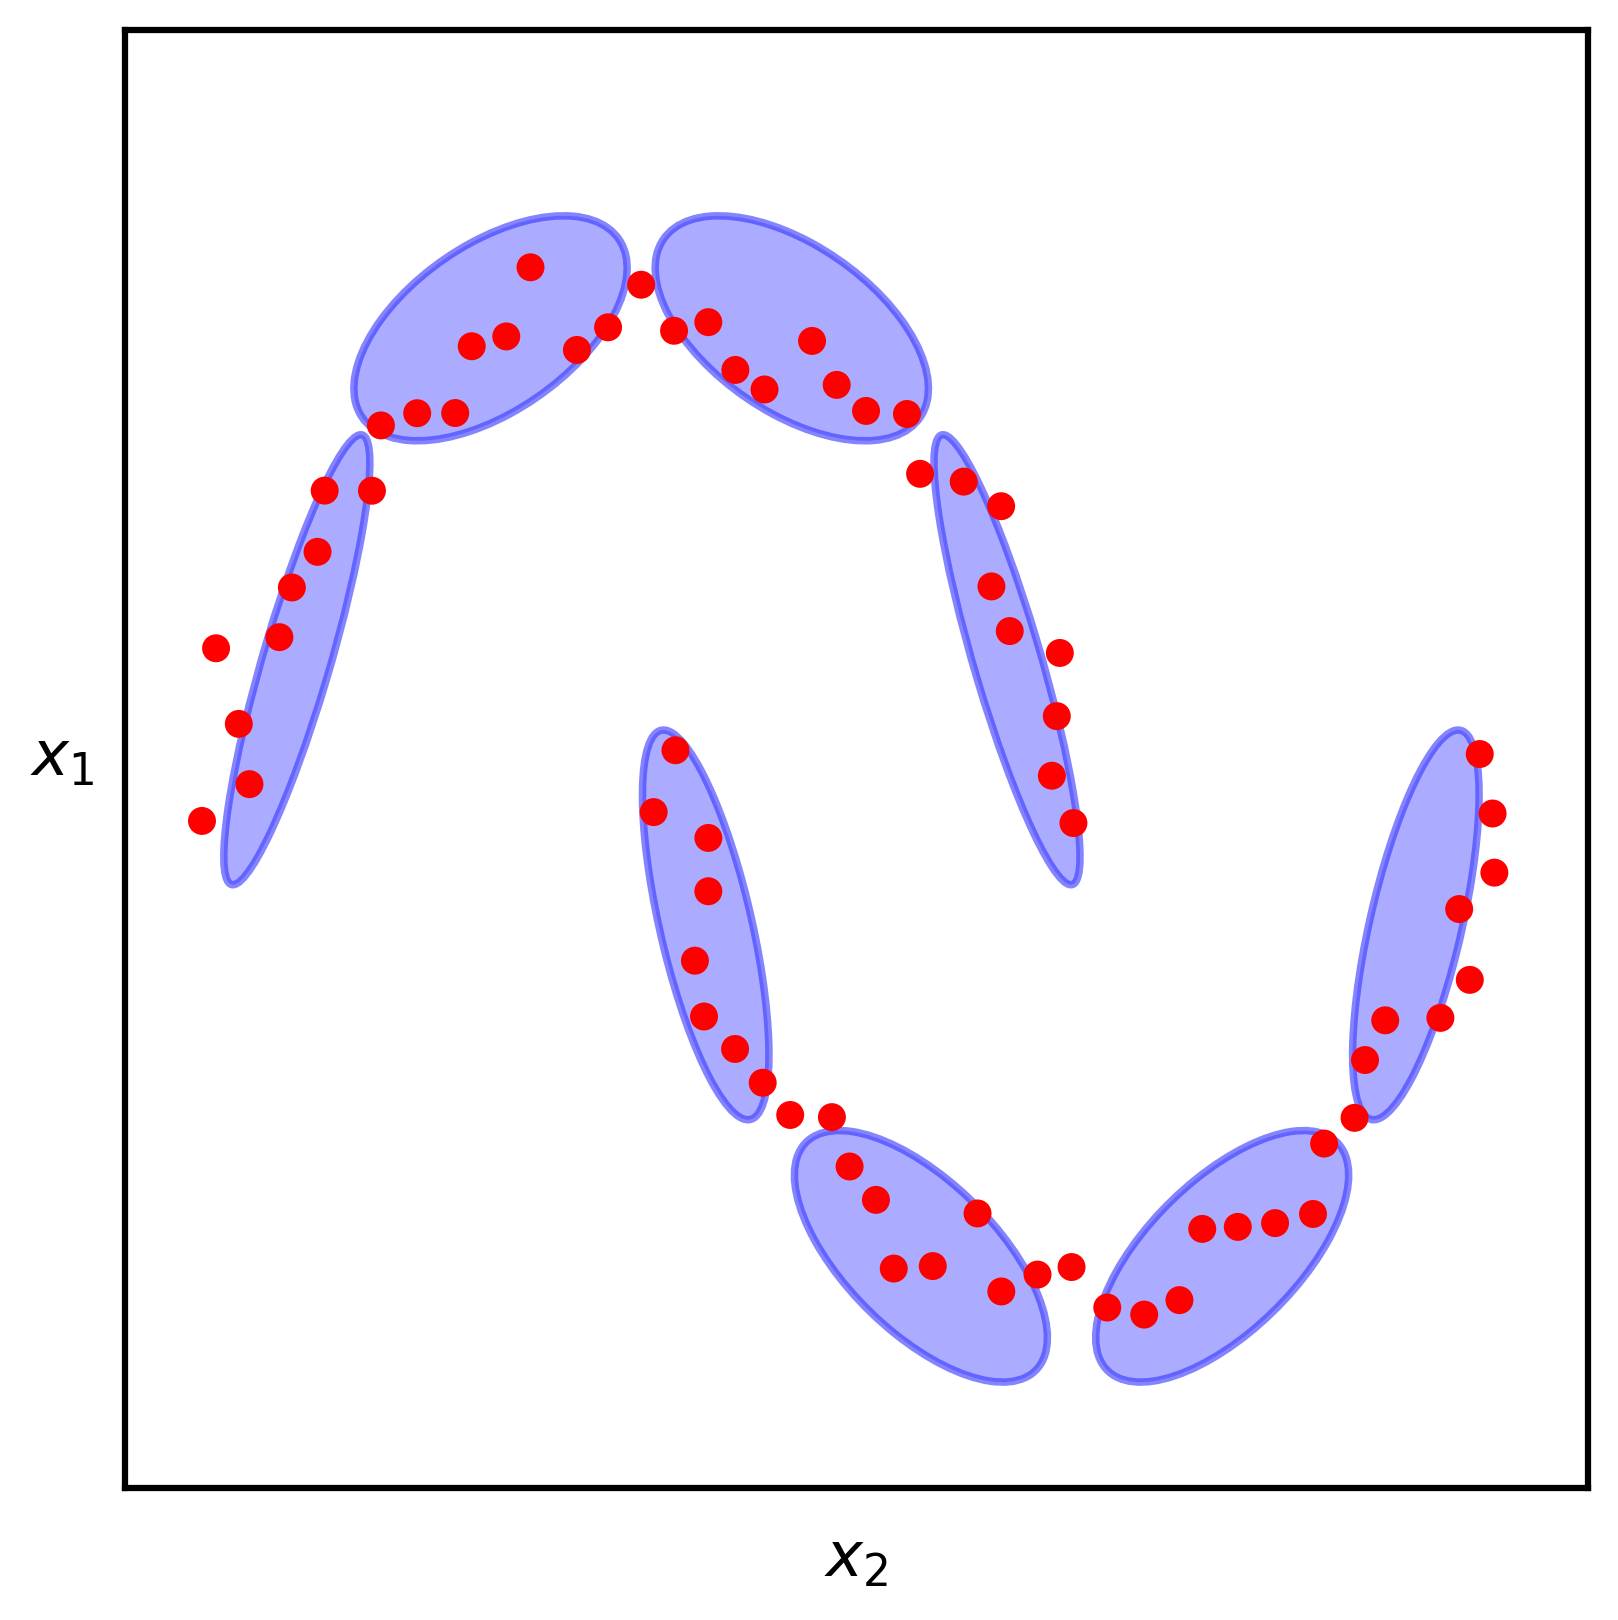

In [4]:
# 負担率のソフトからハードへの転移 (epsilon -> 0) の数値検証
x_test = np.array([[0.2, 0.0]])  # 中心 mu_1 = (0, 0), mu_2 = (1, 0) の中間に近い点
centers_test = np.array([[0.0, 0.0], [1.0, 0.0]])
eps_list = [1.0, 0.2, 0.05, 0.005]
gammas = gmm_to_kmeans_limit(x_test, centers_test, eps_list)

print("Transition of responsibilities gamma(z_{n1}) as epsilon -> 0:")
for eps, g in zip(eps_list, gammas):
    print(f"  epsilon = {eps:6.3f} => gamma_1 = {g[0, 0]:.4f}, gamma_2 = {g[0, 1]:.4f}")

# Figure 15.8: Two Moons データセットに対するGMMフィッティングの生成と表示
fig_path_15_8 = project_root / "15" / "result" / "fig_15_8_gmm_two_moons.png"
generate_figure_15_8(fig_path_15_8)

display(Image(filename=str(fig_path_15_8)))


## 3. 第15.3.3項 ベルヌーイ混合分布 (Mixtures of Bernoulli distributions)

EMアルゴリズムの適用範囲はガウス分布に限定されません。
ここでは、手書き数字画像などの二値ベクトルデータ $\mathbf{x} = (x_1, \ldots, x_D)^T \in \{0, 1\}^D$ をモデル化する**ベルヌーイ混合モデル (Bernoulli mixture model)** を考察します。

---

### モデルの定式化

単一の成分 $k$ が与えられたときの観測 $\mathbf{x}$ の条件付き分布は、各次元 $i \in \{1, \ldots, D\}$ がパラメータ $\mu_{ki} \in [0, 1]$ のもとで独立であると仮定した多変量ベルヌーイ分布です (テキスト式 15.42)：

$$p(\mathbf{x} \mid \boldsymbol{\mu}_k) = \prod_{i=1}^D \mu_{ki}^{x_i} (1 - \mu_{ki})^{1 - x_i} \tag{15.42}$$

成分の線形重ね合わせとして混合分布が定義されます (テキスト式 15.43)：

$$p(\mathbf{x} \mid \boldsymbol{\pi}, \boldsymbol{\mu}) = \sum_{k=1}^K \pi_k p(\mathbf{x} \mid \boldsymbol{\mu}_k) \tag{15.43}$$

このモデルの平均ベクトル $\mathbb{E}[\mathbf{x}]$ および共分散行列 $\operatorname{cov}[\mathbf{x}]$ は次式で与えられます：

$$\mathbb{E}[\mathbf{x}] = \sum_{k=1}^K \pi_k \boldsymbol{\mu}_k$$

個々の成分内では各次元は独立ですが、混合全体としては共分散行列が非対角成分を持ち、変数間の強い相関を捉えることができます。

---

### ベルヌーイEMアルゴリズム

観測データ集合 $\mathbf{X} = \{\mathbf{x}_1, \ldots, \mathbf{x}_N\}$ に対する対数尤度関数は次式です (テキスト式 15.45)：

$$\ln p(\mathbf{X} \mid \boldsymbol{\pi}, \boldsymbol{\mu}) = \sum_{n=1}^N \ln \left\{ \sum_{k=1}^K \pi_k p(\mathbf{x}_n \mid \boldsymbol{\mu}_k) \right\} \tag{15.45}$$

**Eステップ**:
現在のパラメータ値を用いて負担率 $\gamma(z_{nk})$ を計算します (テキスト式 15.46)：

$$\gamma(z_{nk}) = \frac{\pi_k p(\mathbf{x}_n \mid \boldsymbol{\mu}_k)}{\sum_{j=1}^K \pi_j p(\mathbf{x}_n \mid \boldsymbol{\mu}_j)} \tag{15.46}$$

※実装上はアンダーフローを防ぐため、対数領域での log-sum-exp 技法を用いて計算します。

**Mステップ**:
負担率を固定して各パラメータを更新します (テキスト式 15.47 - 15.49)：

$$N_k = \sum_{n=1}^N \gamma(z_{nk}) \tag{15.47}$$

$$\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) \mathbf{x}_n \tag{15.48}$$

$$\pi_k = \frac{N_k}{N} \tag{15.49}$$

---

### MNIST二値手書き数字への適用 (Figure 15.12)

MNISTデータセットから抽出した「2」「3」「4」の手書き二値画像に対してベルヌーイ混合モデルを適用した結果が Figure 15.12 です：
- **(a)** データセットからのサンプル手書き数字。
- **(b)** $K=3$ のベルヌーイ混合モデルを当てはめて得られた3つの成分の平均ベクトル $\boldsymbol{\mu}_k$。各ピクセルが 1 になる確率を表しており、教師なし学習にもかかわらず「2」「4」「3」のプロトタイプ形状が自動的に分離・抽出されている。
- **(c)** 単一のベルヌーイ分布 ($K=1$) を当てはめた場合の平均。全ての数字が重なり合って曖昧な画像となってしまい、データのマルチモーダルな構造を表現できない。


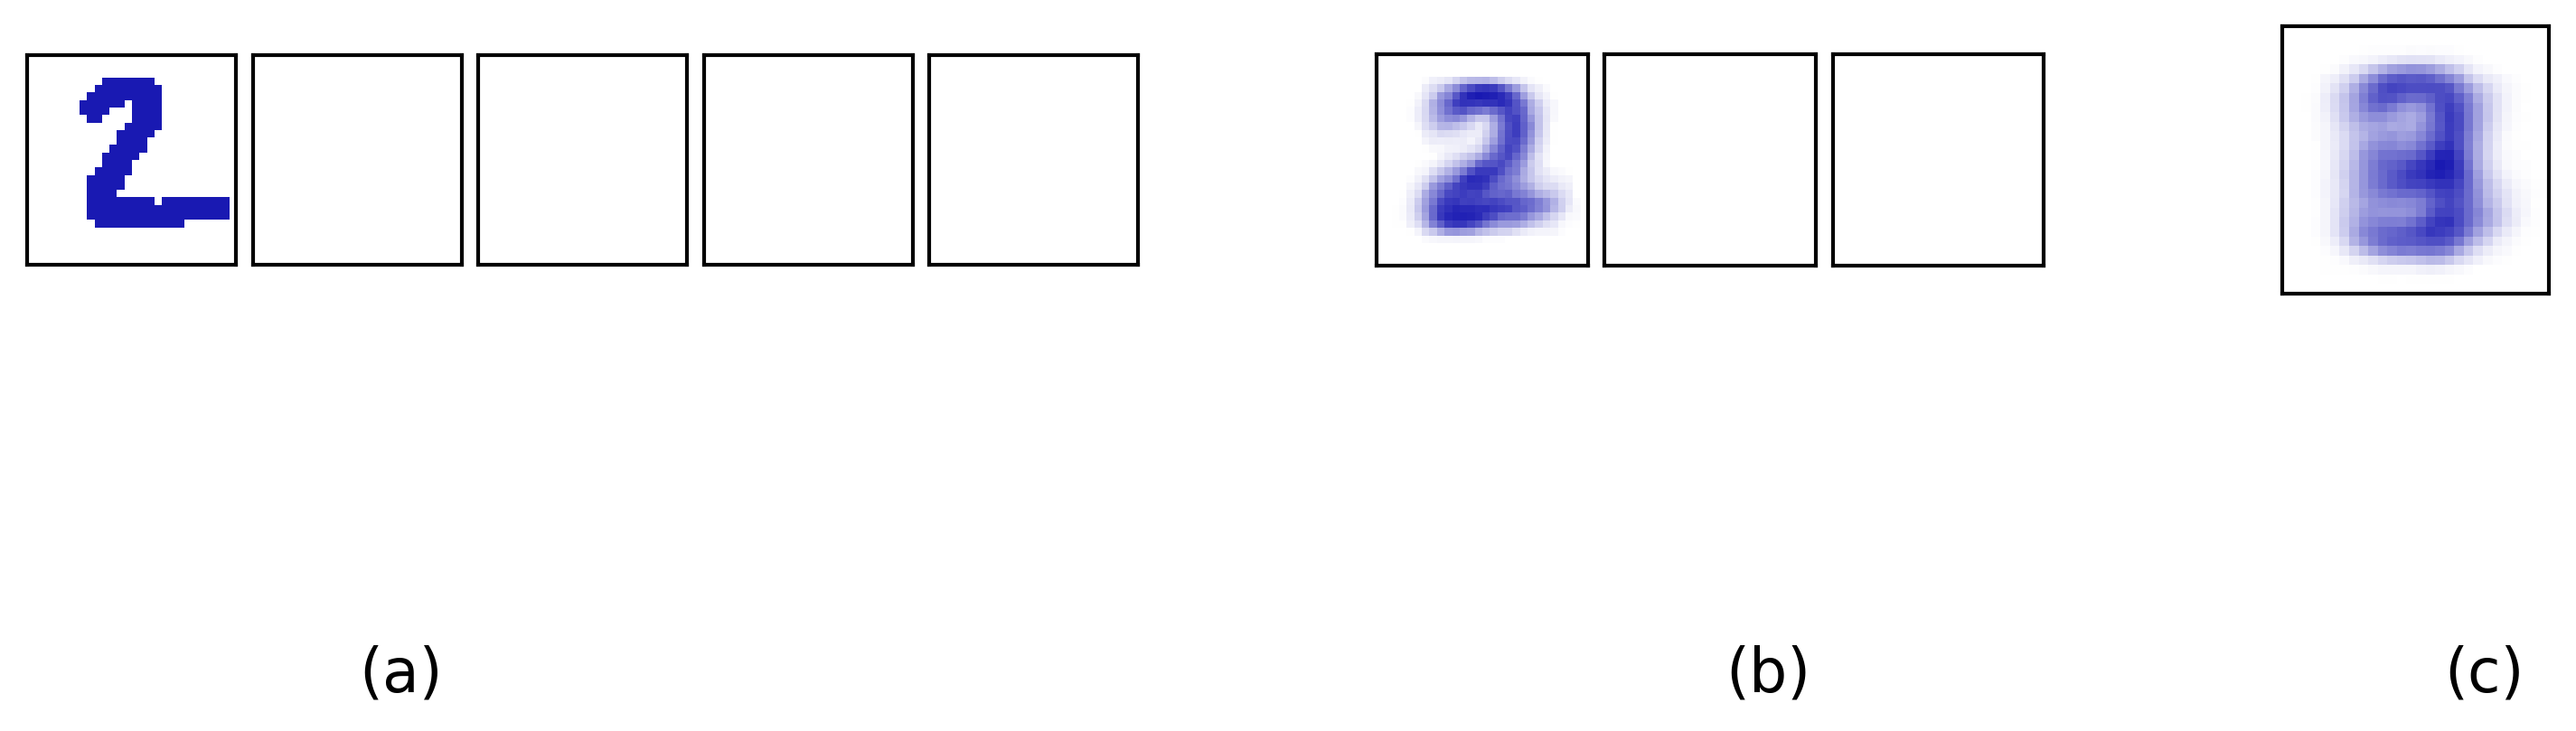

In [5]:
# Figure 15.12: MNIST 二値数字に対するベルヌーイ混合モデルの生成と表示
fig_path_15_12 = project_root / "15" / "result" / "fig_15_12_bernoulli_mixture.png"
generate_figure_15_12(fig_path_15_12)

display(Image(filename=str(fig_path_15_12)))


## 4. 第15.3節のまとめと次節（15.4節 変分下界・ELBO）への展望

本節では、離散潜在変数モデルにおける中核的推論手法である**期待値最大化法 (EMアルゴリズム)** を詳しく学びました。

### クラスタリング手法の比較表

| 項目 | K-means (15.1節) | 混合ガウスモデル (15.2-15.3節) | ベルヌーイ混合モデル (15.3.3項) |
| :--- | :--- | :--- | :--- |
| **データ種別** | 連続値ベクトル $\mathbf{x} \in \mathbb{R}^D$ | 連続値ベクトル $\mathbf{x} \in \mathbb{R}^D$ | 二値ベクトル $\mathbf{x} \in \{0, 1\}^D$ |
| **クラスタ割当** | ハード割当 $r_{nk} \in \{0, 1\}$ | ソフト事後負担率 $\gamma(z_{nk}) \in [0, 1]$ | ソフト事後負担率 $\gamma(z_{nk}) \in [0, 1]$ |
| **成分分布** | ユークリッド距離代表点 | 多変量ガウス分布 $\mathcal{N}(\boldsymbol{\mu}_k, \mathbf{\Sigma}_k)$ | 多変量ベルヌーイ積 $\prod_i \mu_{ki}^{x_i}(1-\mu_{ki})^{1-x_i}$ |
| **クラスタ形状** | 等方球状・等サイズ | 任意の楕円体・回転・広がり | 独立な各特徴量の生起確率 |
| **更新ステップ** | 割当更新 $\to$ 重心再計算 | Eステップ $\to$ Mステップ | Eステップ $\to$ Mステップ |
| **理論的関係** | $\mathbf{\Sigma}_k = \epsilon \mathbf{I}, \epsilon \to 0$ の極限 | 一般の連続密度モデル | 離散特徴量に対するEM適用 |

---

### 次節への展望: 15.4 変分下界 (Evidence Lower Bound; ELBO)
本節では、直感的な観点から「事後確率の期待値（Eステップ）」と「パラメータの最尤更新（Mステップ）」を交互に行うEMアルゴリズムを導入しました。
しかし、なぜこの交互更新によって真の対数尤度 $\ln p(\mathbf{X})$ が必ず単調非減少することが保証されるのでしょうか？

次節（第15.4節）では、**変分下界 (Evidence Lower Bound; ELBO)** および **カルバック・ライブラー情報量 (KL divergence)** を用いてEMアルゴリズムの統一的・普遍的な数学的基礎を確立します。
この理論的枠組みは、後続の変分推論 (Variational Inference) や変分オートエンコーダ (VAE, 第19章) などの現代深層生成モデルの根幹を成す最重要理論となります。
